<a href="https://colab.research.google.com/github/Ebeed-cs/AI-Career-Essentials-Aice-Program/blob/main/DIP_Sec7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# Histogram of an image

![picture](https://drive.google.com/uc?export=view&id=1Df_fDRUiXhpJdr-ojtSubiU23aDT4EuA
)

![Image histogram](http://s10.picofile.com/file/8394782434/understanding_histograms_in_landscape_photography_3.jpg)

![Histogram comparison](http://s11.picofile.com/file/8394782284/hist_2.jpg)



# Histogram Equalization
Histogram equalization is a method to process images in order to adjust the contrast of an image by modifying the intensity distribution of the histogram. The objective of this technique is to give a linear trend to the cumulative probability function associated to the image.

The processing of histogram equalization relies on the use of the cumulative probability function (cdf). The cdf is a cumulative sum of all the probabilities lying in its domain and defined by:

![Histogram Equalization](http://s13.picofile.com/file/8398065676/equalization.png)


![Camera man equalization](https://staff.fnwi.uva.nl/r.vandenboomgaard/IPCV20172018/_images/histeq.png)





In [ ]:
black = cv2.imread('/content/black.png')
white = cv2.imread('/content/white.png')
perfect = cv2.imread('/content/perfect.png')
dull = cv2.imread('/content/dull.png')


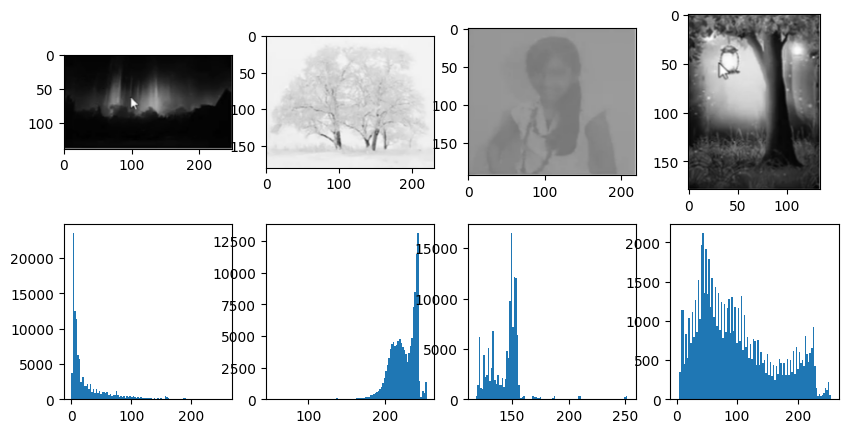

In [ ]:
plt.figure(figsize=(10, 5))

plt.subplot(241), plt.imshow(black, cmap='gray', vmin=0, vmax=255)
plt.subplot(245), plt.hist(black.ravel(), bins=100)

plt.subplot(242), plt.imshow(white, cmap='gray', vmin=0, vmax=255)
plt.subplot(246), plt.hist(white.ravel(), bins=100)

plt.subplot(243), plt.imshow(dull, cmap='gray', vmin=0, vmax=255)
plt.subplot(247), plt.hist(dull.ravel(), bins=100)


plt.subplot(244), plt.imshow(perfect, cmap='gray', vmin=0, vmax=255)
plt.subplot(248), plt.hist(perfect.ravel(), bins=100)
plt.show()

## 1-Histogram of an image

**cv2.calcHist(images, channels, mask, histSize, ranges[, hist[, accumulate]])**

**images** : it is the source image of type uint8 or float32. it should be given in square brackets, ie, "[img]".

**channels** : it is also given in square brackets. It is the index of channel for which we calculate histogram. For example, if input is grayscale image, its value is [0]. For color image, you can pass [0], [1] or [2] to calculate histogram of blue, green or red channel respectively.

**mask** : mask image. To find histogram of full image, it is given as "None". But if you want to find histogram of particular region of image, you have to create a mask image for that and give it as mask. (I will show an example later.)

**histSize** : this represents our BIN count. Need to be given in square brackets. For full scale, we pass [256].

**ranges** : this is our RANGE. Normally, it is [0,256].

Text(0, 0.5, 'Frequency')

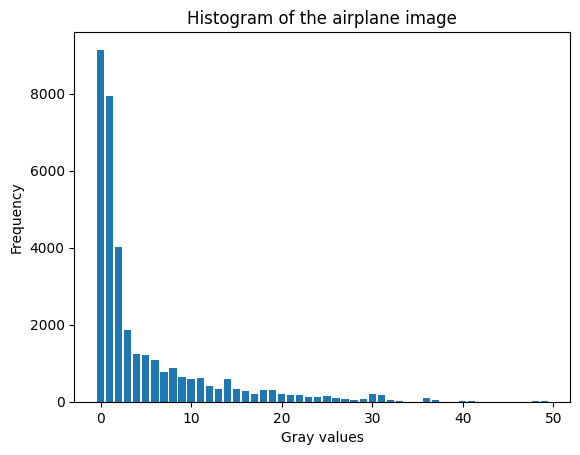

In [ ]:
hist = cv2.calcHist([black],[0],None,[50],[0,256])

# different methods for displaying a histogram
plt.bar(range(50), hist.ravel())
plt.title('Histogram of the black image')
plt.xlabel('Gray values')
plt.ylabel('Frequency')

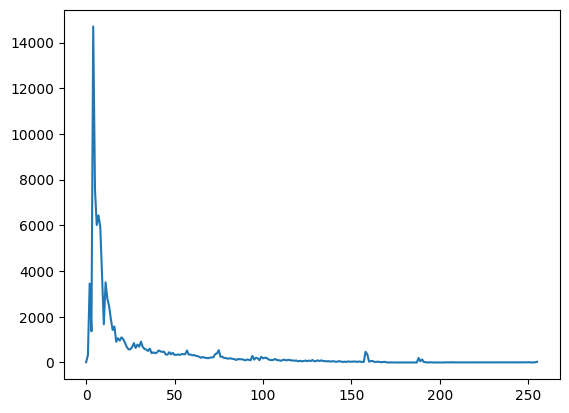

In [ ]:
# Another method
hist,bins = np.histogram(black.ravel(),256,[0,256])
plt.plot(hist)

Let's look at another example.

In [ ]:
# Let's read two other images
high = cv2.imread('/content/hist_highkey.jpg')
low = cv2.imread('/content/hist_lowkey.jpg')

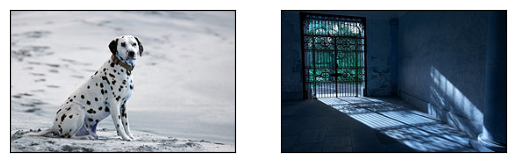

In [ ]:
# show images
plt.subplot(121), plt.imshow(high)
plt.grid(False), plt.xticks([]), plt.yticks([])

plt.subplot(122), plt.imshow(low)
plt.grid(False), plt.xticks([]), plt.yticks([])
plt.show()

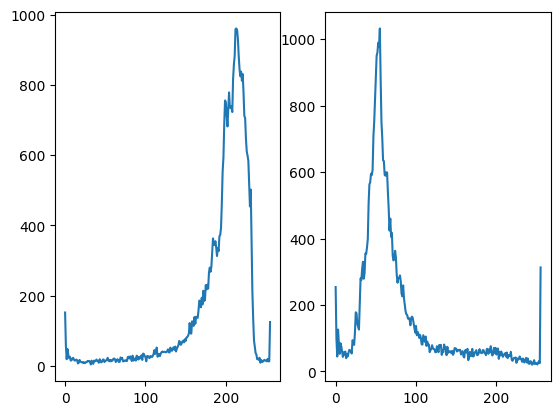

In [ ]:
# Calculate histogram of both images for the last channel.
# Channels can differ from 0 to 2.
hist_high = cv2.calcHist([high],[2],None,[256],[0,256])
hist_low = cv2.calcHist([low],[2],None,[256],[0,256])

# Plot histograms
plt.subplot(121)
plt.plot(hist_high)

plt.subplot(122)
plt.plot(hist_low)

plt.show()

## 2-Cumulative histogram of an image

**Calculate cumulative distribution function (CDF) of an image**

The cumulative histogram of an image is produced by calculating the cumulative sum of that image's histogram. There is no specific function in OpenCV to obtain the CDF of an image; thus we use the cumsum function in Numpy. You can find more about the function [here](https://docs.scipy.org/doc/numpy/reference/generated/numpy.cumsum.html)


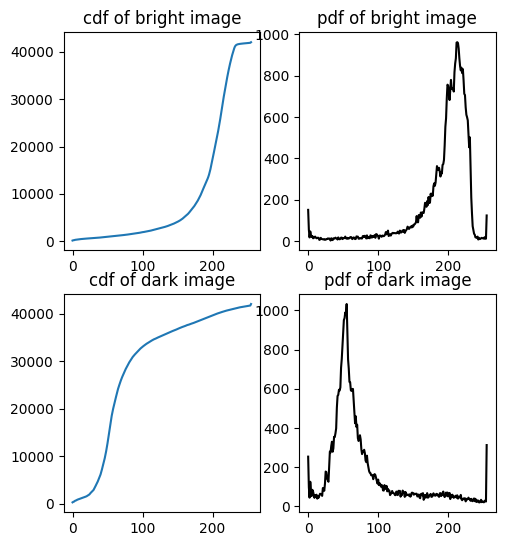

In [ ]:
cdf_low = hist_low.cumsum()
cdf_high = hist_high.cumsum()

# plot cumulative histograms
plt.subplot(221), plt.plot(cdf_high), plt. title('cdf of bright image')
plt.subplot(222), plt.plot(hist_high, 'k'), plt. title('pdf of bright image')

plt.subplot(223), plt.plot(cdf_low), plt. title('cdf of dark image')
plt.subplot(224), plt.plot(hist_low, 'k'), plt. title('pdf of dark image')

# adjust the placement of subplots
plt.subplots_adjust(bottom=2, right=0.8, top=3)

plt.show()

## Histogram equalization

One usual method to stretch the intensity values of an image in order to make its histogram similar to the perfect histogram shape (uniformly distributed), is the _histogram equalization_. In this method, image histogram will be stretched with respect to its cumulative distribution function. Very good explanation of histogram equalization is found in [here](https://docs.opencv.org/2.4.13.7/doc/tutorials/imgproc/histograms/histogram_equalization/histogram_equalization.html).

**cv2.equalizeHist(src[, dst])**

**src** : the only required argument is the original image to be equalized.

In [ ]:
img=cv2.imread('/content/equl.png')

In [ ]:
gray_img=cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

<BarContainer object of 256 artists>

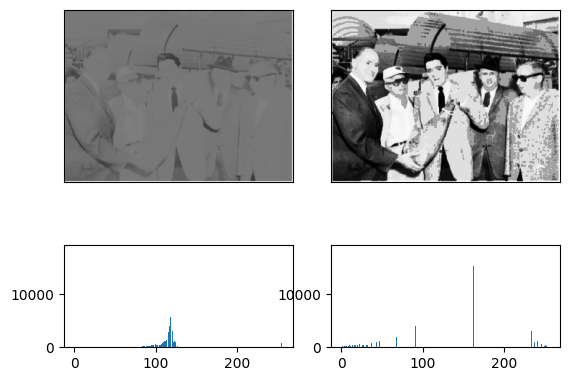

In [ ]:
img_eq = cv2.equalizeHist(gray_img)

grid = plt.GridSpec(3, 4, wspace=0.4, hspace=0.3)

plt.subplot(grid[:2, :2])
plt.imshow(img, cmap='gray')
plt.grid(False), plt.xticks([]), plt.yticks([])

plt.subplot(grid[:2, 2:])
plt.imshow(img_eq, cmap='gray')
plt.grid(False), plt.xticks([]), plt.yticks([])

plt.subplot(grid[2, :2])
plt.bar(range(256),
        cv2.calcHist([img],[0],None,[256],[0,256]).ravel())

plt.subplot(grid[2, 2:])
plt.bar(range(256),
        cv2.calcHist([img_eq],[0],None,[256],[0,256]).ravel())


However, while histogram equalization can be beneficial for many applications, it's not always the best method for every image. It can sometimes over-enhance noise or cause loss of detail in areas where the contrast was already adequate.


In [ ]:
img2=cv2.imread('/content/noise.png')
gray_img2=cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

<BarContainer object of 256 artists>

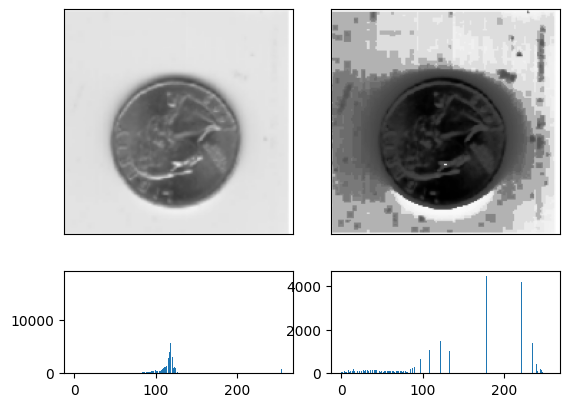

In [ ]:
img_eq = cv2.equalizeHist(gray_img2)

grid = plt.GridSpec(3, 4, wspace=0.4, hspace=0.3)

plt.subplot(grid[:2, :2])
plt.imshow(img2, cmap='gray')
plt.grid(False), plt.xticks([]), plt.yticks([])

plt.subplot(grid[:2, 2:])
plt.imshow(img_eq, cmap='gray')
plt.grid(False), plt.xticks([]), plt.yticks([])

plt.subplot(grid[2, :2])
plt.bar(range(256),
        cv2.calcHist([img],[0],None,[256],[0,256]).ravel())

plt.subplot(grid[2, 2:])
plt.bar(range(256),
        cv2.calcHist([img_eq],[0],None,[256],[0,256]).ravel())
